In [ ]:
import pandas as pd

In [ ]:
day=pd.read_csv(r"C:\Users\kARPOORAPU VANIPRIYA\Downloads\day.csv.zip")

In [ ]:
day

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [ ]:
day.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
day.duplicated().sum()

0

In [ ]:
day.dropna()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [ ]:
day['dteday']=pd.to_datetime(day['dteday'])

In [ ]:
day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [ ]:
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']
day = day.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


In [ ]:
def remove_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include='number').columns
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    df_clean = df[~(
        (df[numeric_cols] < (Q1 - 1.5 * IQR)) |
        (df[numeric_cols] > (Q3 + 1.5 * IQR))
    ).any(axis=1)]
    
    return df_clean
day_clean = remove_outliers_iqr(day)    

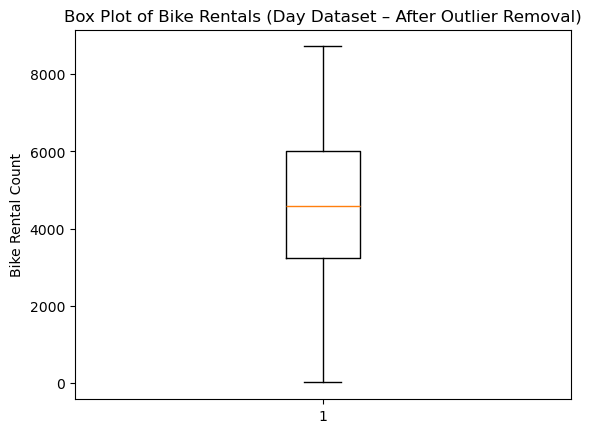

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.boxplot(day_clean["cnt"])
plt.title("Box Plot of Bike Rentals (Day Dataset – After Outlier Removal)")
plt.ylabel("Bike Rental Count")
plt.show()


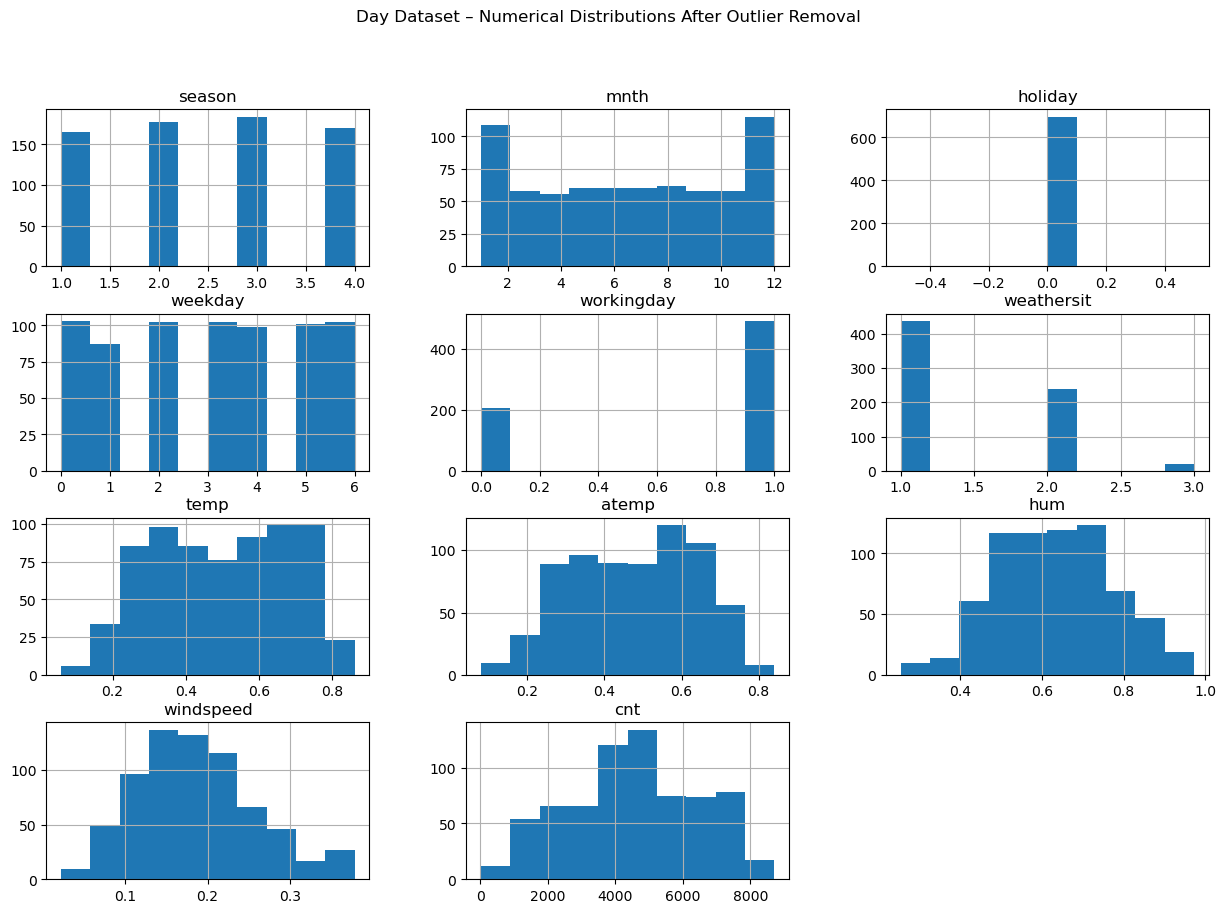

In [ ]:
import matplotlib.pyplot as plt

day_clean.select_dtypes(include='number').hist(figsize=(15,10))
plt.suptitle("Day Dataset – Numerical Distributions After Outlier Removal")
plt.show()



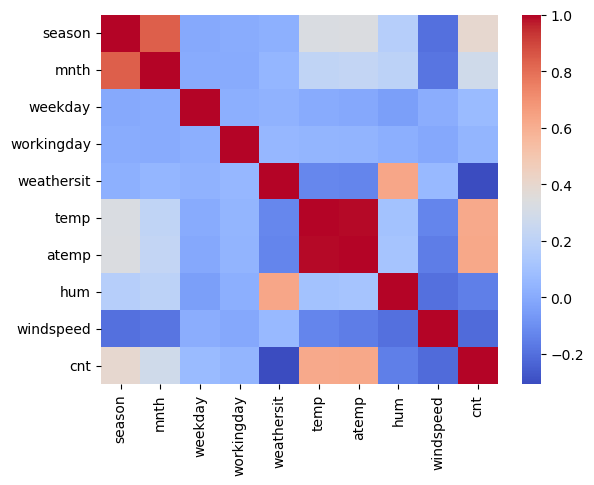

In [ ]:
import seaborn as sns
num_day = day_clean.select_dtypes(include='number')
num_day = num_day.loc[:, num_day.nunique() > 1]

sns.heatmap(num_day.corr(), cmap='coolwarm')
plt.show()

C:\Users\kARPOORAPU VANIPRIYA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


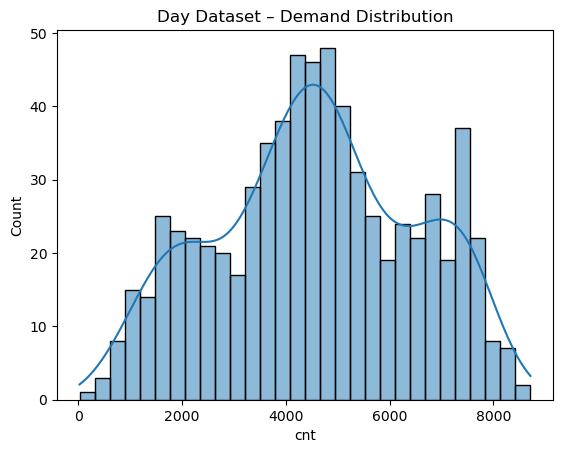

In [ ]:
sns.histplot(day_clean['cnt'], bins=30, kde=True)
plt.title("Day Dataset – Demand Distribution")
plt.show()


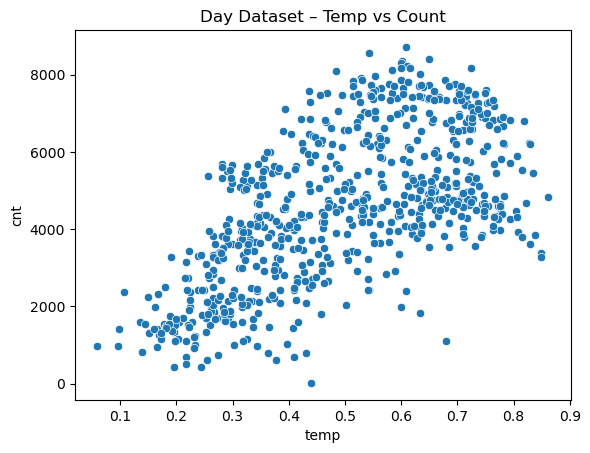

In [ ]:
sns.scatterplot(data=day_clean, x='temp', y='cnt')
plt.title("Day Dataset – Temp vs Count")
plt.show()


In [ ]:
day.isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [ ]:
day.dropna()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600
...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,2114
727,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,3095
728,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,1341
729,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,1796


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
X_day = day.drop('cnt', axis=1)
y_day = day['cnt']

In [ ]:
X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)


In [ ]:
def evaluate_day_model(model, X_day_train, X_day_test, y_day_train, y_day_test):
    model.fit(X_day_train, y_day_train)

    y_day_train_pred = model.predict(X_day_train)
    y_day_test_pred = model.predict(X_day_test)

    return {
        "Train R2": r2_score(y_day_train, y_day_train_pred),
        "Test R2": r2_score(y_day_test, y_day_test_pred),
        "Train MSE": mean_squared_error(y_day_train, y_day_train_pred),
        "Test MSE": mean_squared_error(y_day_test, y_day_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_day_train, y_day_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_day_test, y_day_test_pred))
    }


In [ ]:
dt_day = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

dt_day_metrics = evaluate_day_model(
    dt_day, X_day_train, X_day_test, y_day_train, y_day_test
)

print("Decision Tree (Day) Metrics:\n", dt_day_metrics)



Decision Tree (Day) Metrics:
 {'Train R2': 0.8678768664128091, 'Test R2': 0.34405301415374967, 'Train MSE': 484323.9754707051, 'Test MSE': 2630270.200794585, 'Train RMSE': 695.9338872843491, 'Test RMSE': 1621.8107783568912}


In [ ]:
rf_day = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_day_metrics = evaluate_day_model(
    rf_day, X_day_train, X_day_test, y_day_train, y_day_test
)

print("\nRandom Forest (Day) Metrics:\n", rf_day_metrics)



Random Forest (Day) Metrics:
 {'Train R2': 0.9442077099212703, 'Test R2': 0.5819552560455747, 'Train MSE': 204517.88417289563, 'Test MSE': 1676310.2146182575, 'Train RMSE': 452.23653564577864, 'Test RMSE': 1294.7239916747728}


In [ ]:
xgb_day = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_day_metrics = evaluate_day_model(
    xgb_day, X_day_train, X_day_test, y_day_train, y_day_test
)

print("\nXGBoost (Day) Metrics:\n", xgb_day_metrics)


XGBoost (Day) Metrics:
 {'Train R2': 0.9964575928673054, 'Test R2': 0.5519163728946844, 'Train MSE': 12985.40731408136, 'Test MSE': 1796762.6001338407, 'Train RMSE': 113.95353138047702, 'Test RMSE': 1340.433735823536}


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:
def evaluate_day_model(model):
    y_day_train_pred = model.predict(X_day_train)
    y_day_test_pred = model.predict(X_day_test)

    return {
        "Train R2": r2_score(y_day_train, y_day_train_pred),
        "Test R2": r2_score(y_day_test, y_day_test_pred),
        "Train MSE": mean_squared_error(y_day_train, y_day_train_pred),
        "Test MSE": mean_squared_error(y_day_test, y_day_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_day_train, y_day_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_day_test, y_day_test_pred))
    }

    

In [ ]:
dt_day = DecisionTreeRegressor(random_state=42)

param_grid_dt_day = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_day_grid = GridSearchCV(
    dt_day,
    param_grid_dt_day,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_day_grid.fit(X_day_train, y_day_train)

best_dt_day = dt_day_grid.best_estimator_

dt_day_metrics = evaluate_day_model(best_dt_day)

print("Decision Tree (Day) Best Params:", dt_day_grid.best_params_)
print("Decision Tree (Day) Metrics:", dt_day_metrics)

Decision Tree (Day) Best Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Decision Tree (Day) Metrics: {'Train R2': 0.6527166041253927, 'Test R2': 0.49335419562067717, 'Train MSE': 1273037.2822557932, 'Test MSE': 2031590.0375657673, 'Train RMSE': 1128.2895383082275, 'Test RMSE': 1425.3385694514013}


In [ ]:
rf_day = RandomForestRegressor(random_state=42)

param_grid_rf_day = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_day_grid = GridSearchCV(
    rf_day,
    param_grid_rf_day,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_day_grid.fit(X_day_train, y_day_train)

best_rf_day = rf_day_grid.best_estimator_

rf_day_metrics = evaluate_day_model(best_rf_day)

print("\nRandom Forest (Day) Best Params:", rf_day_grid.best_params_)
print("Random Forest (Day) Metrics:", rf_day_metrics)


Random Forest (Day) Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest (Day) Metrics: {'Train R2': 0.8889996168148415, 'Test R2': 0.5860994542708056, 'Train MSE': 406894.2765994126, 'Test MSE': 1659692.467554525, 'Train RMSE': 637.8826511196339, 'Test RMSE': 1288.290521409874}


In [ ]:
xgb_day = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid_xgb_day = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_day_grid = GridSearchCV(
    xgb_day,
    param_grid_xgb_day,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_day_grid.fit(X_day_train, y_day_train)

best_xgb_day = xgb_day_grid.best_estimator_

xgb_day_metrics = evaluate_day_model(best_xgb_day)

print("\nXGBoost (Day) Best Params:", xgb_day_grid.best_params_)
print("XGBoost (Day) Metrics:", xgb_day_metrics)




XGBoost (Day) Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
XGBoost (Day) Metrics: {'Train R2': 0.8740502981718972, 'Test R2': 0.6004276199335694, 'Train MSE': 461694.01710777025, 'Test MSE': 1602238.209835519, 'Train RMSE': 679.4806966410232, 'Test RMSE': 1265.7954849957077}


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor


In [ ]:


# # Feature engineering
day['is_weekend'] = day['weekday'].isin([0, 6]).astype(int)

# Lag features
day['cnt_lag_1'] = day['cnt'].shift(1)
day['cnt_lag_7'] = day['cnt'].shift(7)
day['cnt_roll_7'] = day['cnt'].shift(1).rolling(7).mean()

day.dropna(inplace=True)

# Remove noisy feature
day.drop(['windspeed'], axis=1, inplace=True)


In [ ]:
X_day = day.drop('cnt', axis=1)
y_day = day['cnt']


In [ ]:
X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)
y_day_train_log = np.log1p(y_day_train)


In [ ]:
best_xgb_day = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=5,
    min_child_weight=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.2,
    objective='reg:squarederror',
    random_state=42
)

best_xgb_day.fit(X_day_train, y_day_train_log)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=6, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_day_train_pred = np.expm1(best_xgb_day.predict(X_day_train))
y_day_test_pred = np.expm1(best_xgb_day.predict(X_day_test))


In [ ]:
print("Train R2:", r2_score(y_day_train, y_day_train_pred))
print("Test R2:", r2_score(y_day_test, y_day_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_day_test, y_day_test_pred)))


Train R2: 0.953616115285211
Test R2: 0.8409879100354563
Test RMSE: 713.8752414339397


In [ ]:
from xgboost import XGBRegressor

best_xgb_day = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=5,
    min_child_weight=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.2,
    objective='reg:squarederror',
    random_state=42
)

best_xgb_day.fit(X_day, np.log1p(y_day))


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=6, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_day_train_pred = np.expm1(best_xgb_day.predict(X_day_train))
y_day_test_pred = np.expm1(best_xgb_day.predict(X_day_test))


In [ ]:
# Get last known row as base
current_row = day.iloc[-1].copy()

future_predictions = []
future_days = []

month_days = {
    1:31, 2:28, 3:31, 4:30, 5:31, 6:30,
    7:31, 8:31, 9:30, 10:31, 11:30, 12:31
}

current_day_of_month = 1  # academic assumption

for i in range(1, 7):
    # Prepare input
    input_features = current_row.drop('cnt')

    # Predict
    pred_log = best_xgb_day.predict(pd.DataFrame([input_features]))[0]
    pred = int(max(0, np.expm1(pred_log)))

    future_predictions.append(pred)
    future_days.append(f"Day +{i}")

    # ---- UPDATE FEATURES DYNAMICALLY ----
    # Update lag values
    current_row['cnt_lag_7'] = current_row['cnt_lag_1']
    current_row['cnt_lag_1'] = pred
    current_row['cnt_roll_7'] = (
        current_row['cnt_roll_7'] * 6 + pred
    ) / 7

    # Update weekday
    current_row['weekday'] = (current_row['weekday'] + 1) % 7
    current_row['is_weekend'] = 1 if current_row['weekday'] in [0,6] else 0

    # Update month correctly
    current_day_of_month += 1
    if current_day_of_month > month_days[current_row['mnth']]:
        current_day_of_month = 1
        current_row['mnth'] = (current_row['mnth'] % 12) + 1


In [ ]:
for day, val in zip(future_days, future_predictions):
    print(f"{day} prediction: {val} bike rentals")


Day +1 prediction: 2236 bike rentals
Day +2 prediction: 2363 bike rentals
Day +3 prediction: 2402 bike rentals
Day +4 prediction: 2350 bike rentals
Day +5 prediction: 2304 bike rentals
Day +6 prediction: 2225 bike rentals


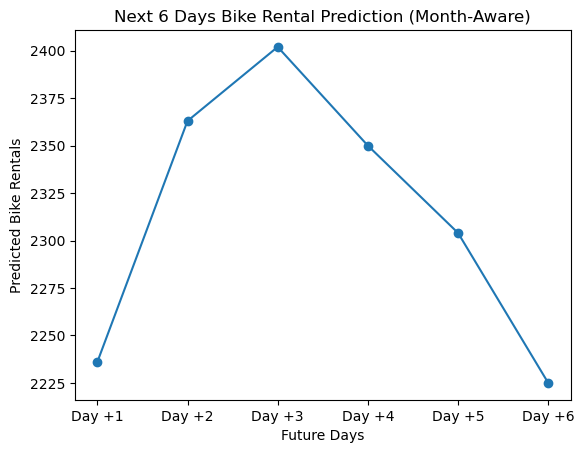

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(future_days, future_predictions, marker='o')
plt.xlabel("Future Days")
plt.ylabel("Predicted Bike Rentals")
plt.title("Next 6 Days Bike Rental Prediction (Month-Aware)")
plt.show()


In [ ]:
day_model=best_xgb_day

In [ ]:
import os
import pickle
os.makedirs("models", exist_ok=True)


In [ ]:
with open("models/day_model.pkl", "wb") as f:
    pickle.dump(day_model, f)

print("day model saved successfully!")


day model saved successfully!
